### 1. Cohort Analysis (Temporal Trends)
**Author:** Saicharan K

#### Goal
Analyze how the data science landscape has evolved over time (2020-2022).
**Key Questions:**
1. **Salary Inflation:** Have salaries increased year-over-year?
2. **Experience Cohorts:** Is the gap between Junior and Senior pay widening?
3. **Remote Adoption:** How has the prevalence of remote work shifted since 2020?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
df = pd.read_csv('../data/ds_salaries_cleaned.csv')

# Ensure work_year is treated as an integer/category, not a float
print(f"Years available: {df['work_year'].unique()}")

Years available: [2020 2021 2022]


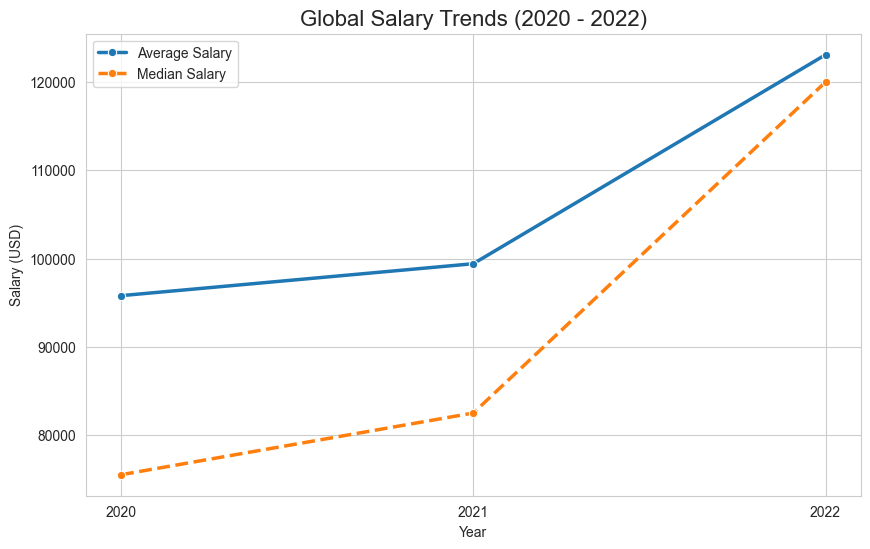

Total Salary Growth (2020-2022): 28.47%


In [8]:
# Group by year and calculate mean/median
trend_data = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(10, 6))

# plot Mean
sns.lineplot(x='work_year', y='mean', data=trend_data, marker='o', label='Average Salary', linewidth=2.5)
# plot Median
sns.lineplot(x='work_year', y='median', data=trend_data, marker='o', linestyle='--', label='Median Salary', linewidth=2.5)

plt.title('Global Salary Trends (2020 - 2022)', fontsize=16)
plt.ylabel('Salary (USD)')
plt.xlabel('Year')
plt.xticks([2020, 2021, 2022]) # Force integer ticks
plt.legend()
plt.show()

# Calculate the % increase
growth = (trend_data.iloc[-1]['mean'] - trend_data.iloc[0]['mean']) / trend_data.iloc[0]['mean'] * 100
print(f"Total Salary Growth (2020-2022): {growth:.2f}%")

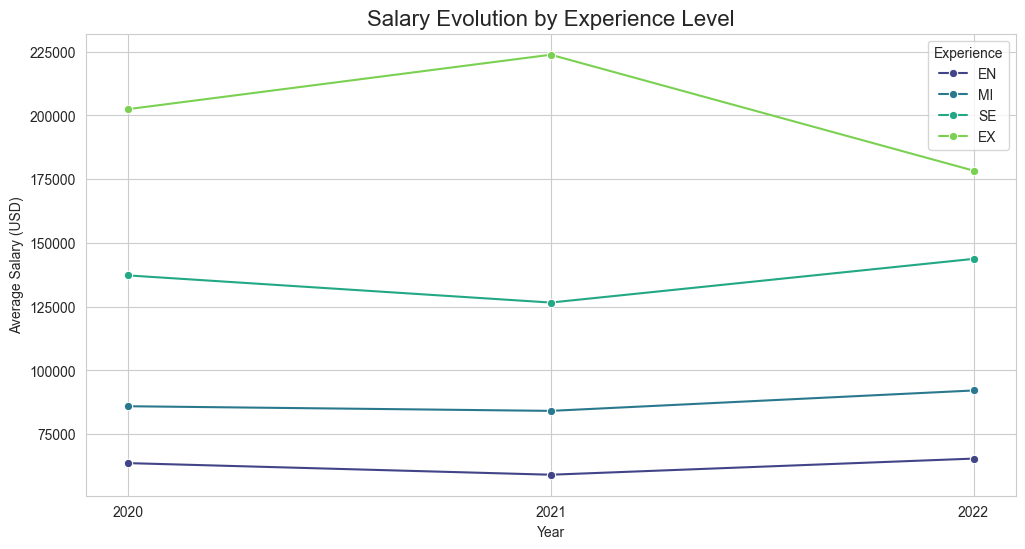

In [9]:
plt.figure(figsize=(12, 6))

# Calculate mean salary per year per experience level
exp_trend = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().reset_index()

# Lineplot with hue
sns.lineplot(x='work_year', y='salary_in_usd', hue='experience_level', 
             data=exp_trend, marker='o', palette='viridis',
             hue_order=['EN', 'MI', 'SE', 'EX'])

plt.title('Salary Evolution by Experience Level', fontsize=16)
plt.ylabel('Average Salary (USD)')
plt.xlabel('Year')
plt.xticks([2020, 2021, 2022])
plt.legend(title='Experience')
plt.show()

In [ ]:
# empty cell

### 2. The Remote Work Revolution
We analyze the adoption of remote work over the 3-year period.
**Hypothesis:** The "Remote (100)" category will dominate the 2022 cohort, replacing the "Hybrid (50)" model often seen in 2020.

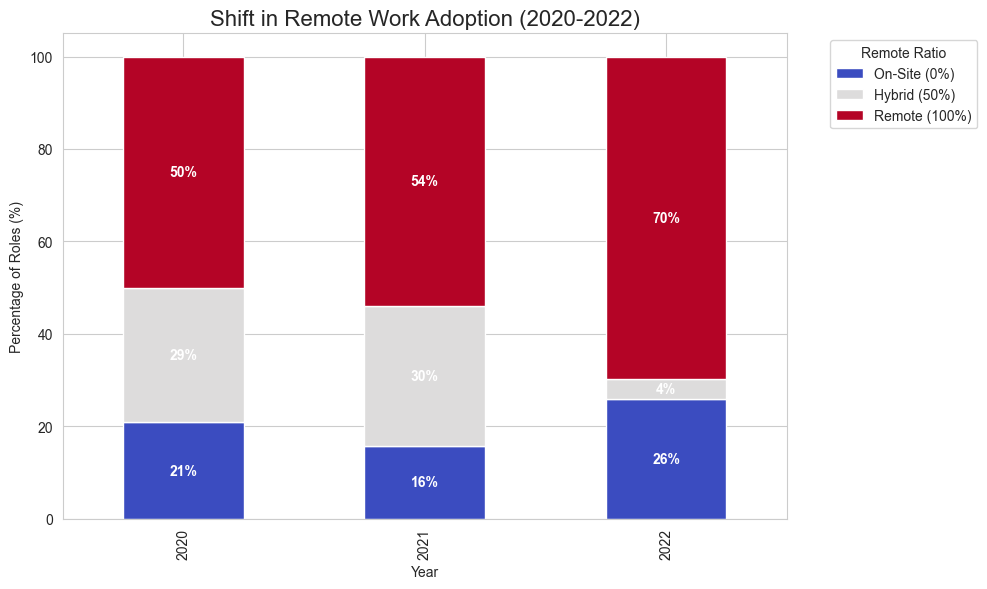

In [10]:
# Create a cross-tabulation of Year vs Remote Ratio
remote_trend = pd.crosstab(df['work_year'], df['remote_ratio'], normalize='index') * 100

# Plot Stacked Bar Chart
ax = remote_trend.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')

plt.title('Shift in Remote Work Adoption (2020-2022)', fontsize=16)
plt.ylabel('Percentage of Roles (%)')
plt.xlabel('Year')
plt.legend(title='Remote Ratio', labels=['On-Site (0%)', 'Hybrid (50%)', 'Remote (100%)'], bbox_to_anchor=(1.05, 1))

# Add percentage labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#end of notebook 5 ---